In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Carregar os dados
dados = pd.read_csv("dados.xls")
dados.head()

,Carimbo de data/hora,Pontuação,Declaração de concordância com o termo dessa pesquisa,Qual é a sua faixa etária?,Qual é o seu gênero?,"Qual é seu salário mensal?\n(Salário mínimo atual: R$ 1.621,00)",Qual área você está cursando/atuando no momento?,"Em uma escala de 0 a 10, como você avalia seu bem-estar emocional atualmente?",Você faz algum acompanhamento psicólogo?(Observação: com profissional humano),"Qual(is) IA(s) você mais utiliza? Você pode marcar até três opções nessa pergunta.\nObs: Se você não utiliza, só marcar em ""Outro"" e falar que não utiliza.",...,"Em uma escala de 0 a 10, você acredita que a IA pode desenvolver empatia real?",Com que frequência você tem utilizado a IA para apoio emocional ou desabafo?,"Após conversar com IA, como fica seu bem-estar?","Em uma escala de 0 a 10, com que frequência você recorre à IA em momentos de estresse ou ansiedade?","Em uma escala de 0 a 10, o quanto você sente um nível de dependência emocional ao usar IA?",Conversar com IA já influenciou decisões importantes da sua vida?,Você sente que conversar com IA pode substituir terapia profissional?,Você se sente mais à vontade desabafando com IA do que com pessoas reais?,Você já compartilhou algo com IA que nunca contou a outra pessoa?,Se quiser compartilhar conosco (é opcional): como a IA impacta sua vida emocional?
0,23/04/2026 01:40:10,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Masculino,Não possuo renda,Engenharia da Computação,7,Não,"ChatGPT, Google Gemini, Claude",...,6,Nunca,Indiferente,3,4,Não,"Não, de jeito nenhum.",Não,Não,nao quero
1,23/04/2026 01:44:03,NaN,Declaro que li e estou ciente das informações ...,50+ anos,Feminino,De 1 a 3 salários mínimos,Educação Física,9,Sim,ChatGPT,...,4,Nunca,Indiferente,0,0,Não,"Não, de jeito nenhum.",Não,Não,NaN
2,23/04/2026 01:44:06,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Masculino,Não possuo renda,Ciência da Computação,3,Sim,"ChatGPT, Google Gemini, Microsoft Copilot, Claude",...,4,Nunca,Indiferente,0,0,Sim,"Não, de jeito nenhum.",Não,Não,NaN
3,23/04/2026 06:09:25,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Masculino,Até 1 salário mínimo,Administração,3,Não,"ChatGPT, Meta AI, DeepSeek",...,0,Nunca,Indiferente,0,0,Não sei dizer,"Não, de jeito nenhum.",Não,Sim,NaN
4,23/04/2026 07:54:04,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Feminino,Não possuo renda,Ciência da Computação,5,Não,"ChatGPT, Google Gemini, Microsoft Copilot",...,0,Nunca,Melhora,2,1,Não sei dizer,"Não, de jeito nenhum.",Não,Não,NaN


In [3]:
# Quais colunas irei usar / analisar?
dados.columns

Index(['Carimbo de data/hora', 'Pontuação',
       'Declaração de concordância com o termo dessa pesquisa',
       'Qual é a sua faixa etária?', 'Qual é o seu gênero?',
       'Qual é seu salário mensal?\n(Salário mínimo atual: R$ 1.621,00)',
       'Qual área você está cursando/atuando no momento?',
       'Em uma escala de 0 a 10,  como você avalia seu bem-estar emocional atualmente?',
       'Você faz algum acompanhamento psicólogo?(Observação: com profissional humano)',
       'Qual(is) IA(s) você mais utiliza? Você pode marcar até três opções nessa pergunta.\nObs: Se você não utiliza, só marcar em "Outro" e falar que não utiliza.',
       'Você possui um plano pago do seu serviço de IA?',
       'Com que frequência você utiliza IA no seu dia a dia? ',
       '  Você costuma dar nome à IA que utiliza?  ',
       '  Como você se refere à IA durante conversas?  ',
       '  Em uma escala de 0 a 10, quão “humana” a IA parece para você?  ',
       'Em uma escala de 0 a 10,  você acredi

In [4]:
"""
Dependente: Bem estar emocional

Independentes:
Frequencia de uso da IA para apoio emocional
Frequencia de uso da IA no dia a dia
IA parece humana
IA pode ter empatia
"""

analise1 = dados[[
    'Qual é o seu gênero?',
    'Em uma escala de 0 a 10,  como você avalia seu bem-estar emocional atualmente?',
    'Com que frequência você tem utilizado a IA para apoio emocional ou desabafo?  ',
    'Com que frequência você utiliza IA no seu dia a dia? ',
    '  Em uma escala de 0 a 10, quão “humana” a IA parece para você?  ',
    'Em uma escala de 0 a 10,  você acredita que a IA pode desenvolver empatia real? '
    ]]

In [5]:
analise1

,Qual é o seu gênero?,"Em uma escala de 0 a 10, como você avalia seu bem-estar emocional atualmente?",Com que frequência você tem utilizado a IA para apoio emocional ou desabafo?,Com que frequência você utiliza IA no seu dia a dia?,"Em uma escala de 0 a 10, quão “humana” a IA parece para você?","Em uma escala de 0 a 10, você acredita que a IA pode desenvolver empatia real?"
0,Masculino,7,Nunca,Às vezes,5,6
1,Feminino,9,Nunca,Às vezes,0,4
2,Masculino,3,Nunca,Frequentemente,7,4
3,Masculino,3,Nunca,Nunca,0,0
4,Feminino,5,Nunca,Às vezes,4,0
...,...,...,...,...,...,...
147,Feminino,7,Raramente,Frequentemente,7,0
148,Masculino,6,Raramente,Frequentemente,5,5
149,Masculino,8,Raramente,Todos os dias,5,2
150,Masculino,7,Nunca,Às vezes,0,0


In [6]:
# Renomeando as colunas
analise1.columns = ["genero","bem-estar emocional", "frequencia-ia-emocional", "frequencia-ia-diario", "humanidade-ia", "empatia-ia"]

In [7]:
analise1

,genero,bem-estar emocional,frequencia-ia-emocional,frequencia-ia-diario,humanidade-ia,empatia-ia
0,Masculino,7,Nunca,Às vezes,5,6
1,Feminino,9,Nunca,Às vezes,0,4
2,Masculino,3,Nunca,Frequentemente,7,4
3,Masculino,3,Nunca,Nunca,0,0
4,Feminino,5,Nunca,Às vezes,4,0
...,...,...,...,...,...,...
147,Feminino,7,Raramente,Frequentemente,7,0
148,Masculino,6,Raramente,Frequentemente,5,5
149,Masculino,8,Raramente,Todos os dias,5,2
150,Masculino,7,Nunca,Às vezes,0,0


In [8]:
# Fazendo a analise dos valores das colunas
analise1["bem-estar emocional"].unique()

array([ 7,  9,  3,  5,  6,  8,  4,  0,  2,  1, 10])

In [9]:
analise1["frequencia-ia-emocional"].unique()

<StringArray>
['Nunca', 'Raramente', 'Frequentemente', 'Às vezes']
Length: 4, dtype: str

In [10]:
analise1["frequencia-ia-diario"].unique()

<StringArray>
['Às vezes', 'Frequentemente', 'Nunca', 'Todos os dias']
Length: 4, dtype: str

In [11]:
analise1["humanidade-ia"].unique()

array([ 5,  0,  7,  4,  6,  2,  1,  3, 10,  8,  9])

In [12]:
analise1["empatia-ia"].unique()

array([ 6,  4,  0,  5,  8,  2, 10,  3,  1,  9,  7])

In [13]:
# É necessario fazer uma troca de valores em frequencia-ia-emocional e frequencia-ia-diario
def troca_frequenciaIaEmocional(x):
    if x == "Nunca":
        return 0
    if x == "Raramente":
        return 1
    if x == "Às vezes":
        return 2
    if x == "Frequentemente":
        return 3
    
def troca_frequenciaIaDiario(x):
    if x == "Nunca":
        return 0
    if x == "Às vezes":
        return 1
    if x == "Frequentemente":
        return 2
    if x == "Todos os dias":
        return 3
    

In [14]:
analise1["frequencia-ia-emocional"] = analise1["frequencia-ia-emocional"].apply(troca_frequenciaIaEmocional)
analise1["frequencia-ia-diario"] = analise1["frequencia-ia-diario"].apply(troca_frequenciaIaDiario)

In [15]:
analise1

,genero,bem-estar emocional,frequencia-ia-emocional,frequencia-ia-diario,humanidade-ia,empatia-ia
0,Masculino,7,0,1,5,6
1,Feminino,9,0,1,0,4
2,Masculino,3,0,2,7,4
3,Masculino,3,0,0,0,0
4,Feminino,5,0,1,4,0
...,...,...,...,...,...,...
147,Feminino,7,1,2,7,0
148,Masculino,6,1,2,5,5
149,Masculino,8,1,3,5,2
150,Masculino,7,0,1,0,0


In [16]:
# So confirmando
analise1["frequencia-ia-emocional"].unique()

array([0, 1, 3, 2])

In [17]:
analise1["frequencia-ia-diario"].unique()


array([1, 2, 0, 3])

In [18]:
# Analise de variaveis basica
for x in analise1.columns:
    print(f"Dados da coluna: {x}")
    display(analise1[x].describe())

Dados da coluna: genero


count          152
unique           3
top       Feminino
freq            77
Name: genero, dtype: object

Dados da coluna: bem-estar emocional


count    152.000000
mean       6.276316
std        2.558449
min        0.000000
25%        4.750000
50%        7.000000
75%        8.000000
max       10.000000
Name: bem-estar emocional, dtype: float64

Dados da coluna: frequencia-ia-emocional


...

count    152.000000
mean       1.717105
std        0.923697
min        0.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        3.000000
Name: frequencia-ia-diario, dtype: float64

Dados da coluna: humanidade-ia


count    152.000000
mean       4.151316
std        2.761514
min        0.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       10.000000
Name: humanidade-ia, dtype: float64

Dados da coluna: empatia-ia


count    152.000000
mean       2.842105
std        3.086191
min        0.000000
25%        0.000000
50%        2.000000
75%        5.000000
max       10.000000
Name: empatia-ia, dtype: float64

In [19]:
# Fazendo reparticao homens e mulheres
analiseHomens1 = analise1[analise1["genero"] == "Masculino"]
analiseMulheres1 = analise1[analise1["genero"] == "Feminino"]

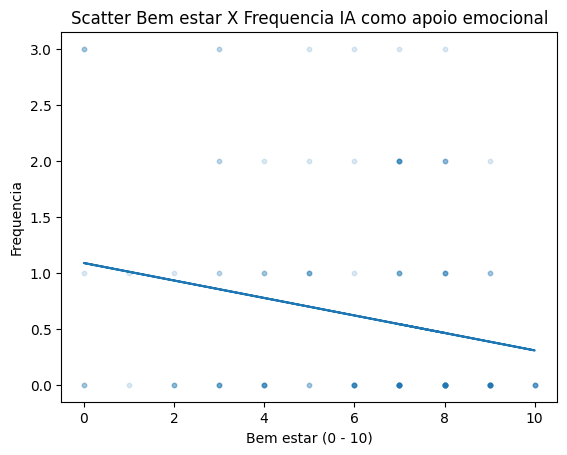

Correlação: -0.2181533818467412
R²: 0.04759089801117008


In [20]:
# Graficos Scatter + linha

xData, yData = analise1["bem-estar emocional"], analise1["frequencia-ia-emocional"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Frequencia IA como apoio emocional")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Frequencia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

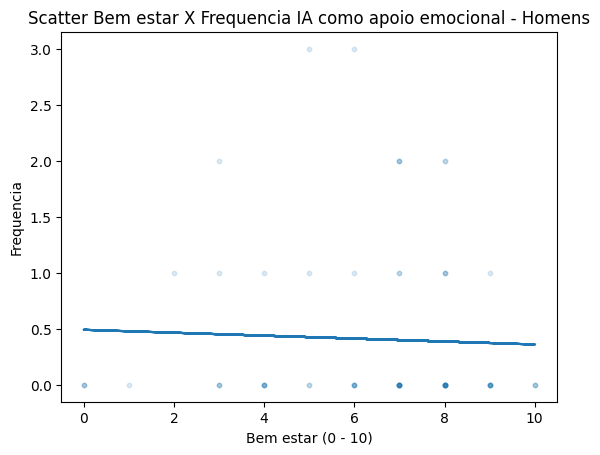

Correlação: -0.04160217976552447
R²: 0.0017307413612430139


In [21]:
# Para homens
xData, yData = analiseHomens1["bem-estar emocional"], analiseHomens1["frequencia-ia-emocional"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Frequencia IA como apoio emocional - Homens")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Frequencia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))


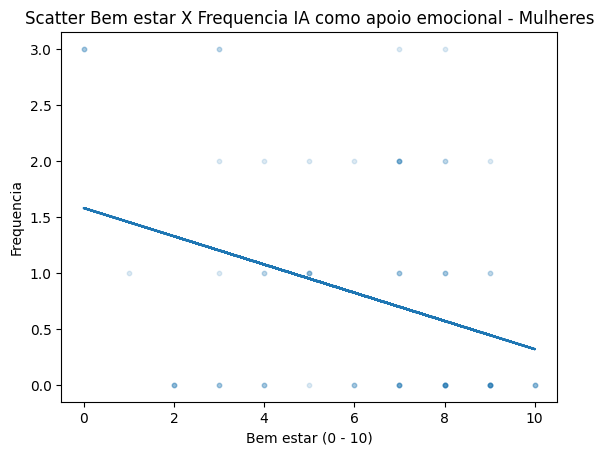

Correlação: -0.3276492112238375
R²: 0.10735400561560288


In [22]:
# Para Mulheres
xData, yData = analiseMulheres1["bem-estar emocional"], analiseMulheres1["frequencia-ia-emocional"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Frequencia IA como apoio emocional - Mulheres")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Frequencia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

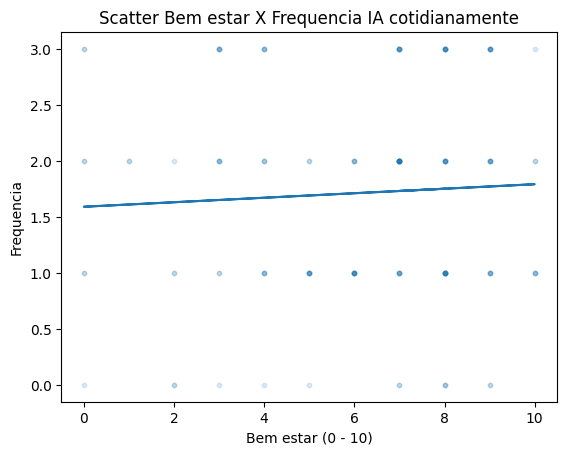

Correlação: 0.055714449279315195
R²: 0.0031040998584973855


In [23]:
xData, yData = analise1["bem-estar emocional"], analise1["frequencia-ia-diario"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Frequencia IA cotidianamente")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Frequencia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

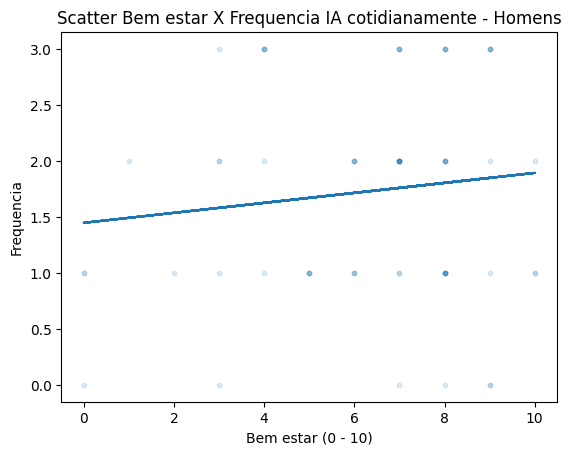

Correlação: 0.11728294717542176
R²: 0.01375528969815277


In [24]:
xData, yData = analiseHomens1["bem-estar emocional"], analiseHomens1["frequencia-ia-diario"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Frequencia IA cotidianamente - Homens")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Frequencia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

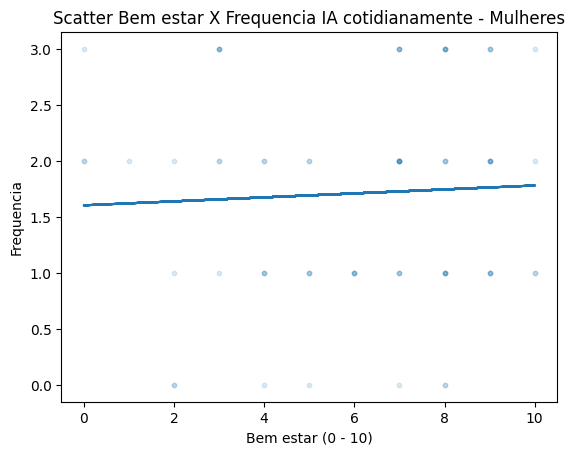

Correlação: 0.05041189215529299
R²: 0.0025413588706768905


In [25]:
xData, yData = analiseMulheres1["bem-estar emocional"], analiseMulheres1["frequencia-ia-diario"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Frequencia IA cotidianamente - Mulheres")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Frequencia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

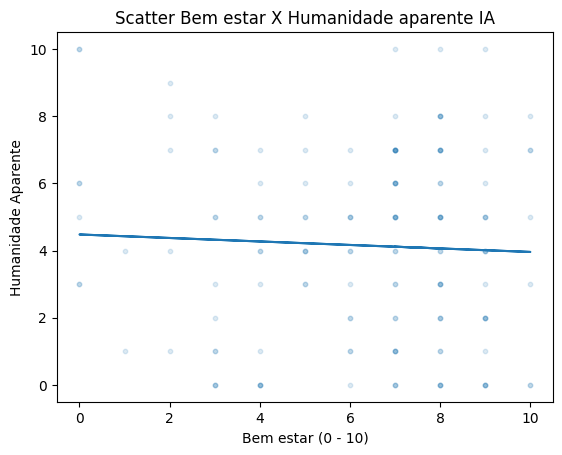

Correlação: -0.04813755788703889
R²: 0.00231722447932802


In [26]:
xData, yData = analise1["bem-estar emocional"], analise1["humanidade-ia"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Humanidade aparente IA")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Humanidade Aparente")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

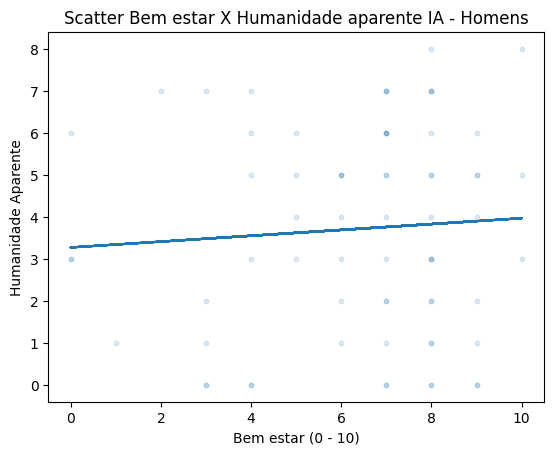

Correlação: 0.06949725344278902
R²: 0.004829868236091251


In [27]:
xData, yData = analiseHomens1["bem-estar emocional"], analiseHomens1["humanidade-ia"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Humanidade aparente IA - Homens")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Humanidade Aparente")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

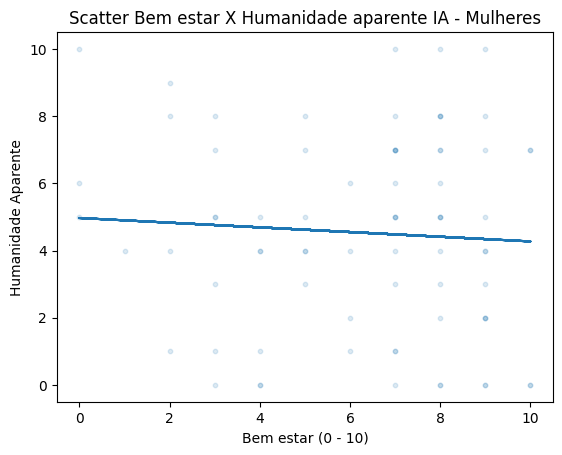

Correlação: -0.06353342922640673
R²: 0.004036496629266833


In [28]:
xData, yData = analiseMulheres1["bem-estar emocional"], analiseMulheres1["humanidade-ia"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Humanidade aparente IA - Mulheres")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Humanidade Aparente")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

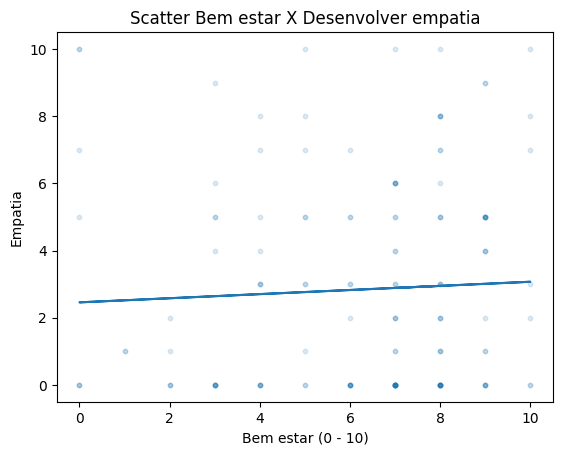

Correlação: 0.05085368569703979
R²: 0.0025860973489733093


In [29]:
xData, yData = analise1["bem-estar emocional"], analise1["empatia-ia"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Desenvolver empatia")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Empatia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

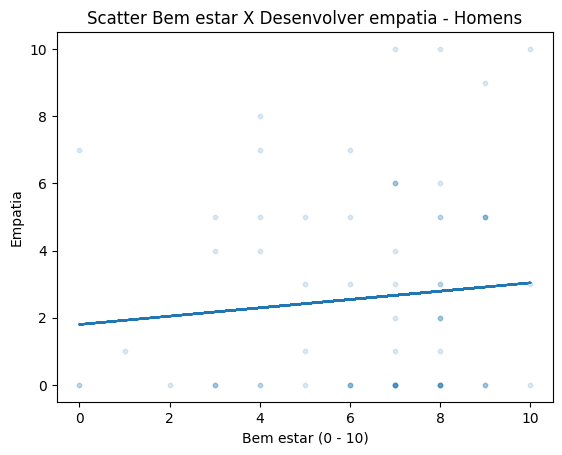

Correlação: 0.10050843081330241
R²: 0.010101944664552397


In [30]:
xData, yData = analiseHomens1["bem-estar emocional"], analiseHomens1["empatia-ia"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Desenvolver empatia - Homens")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Empatia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

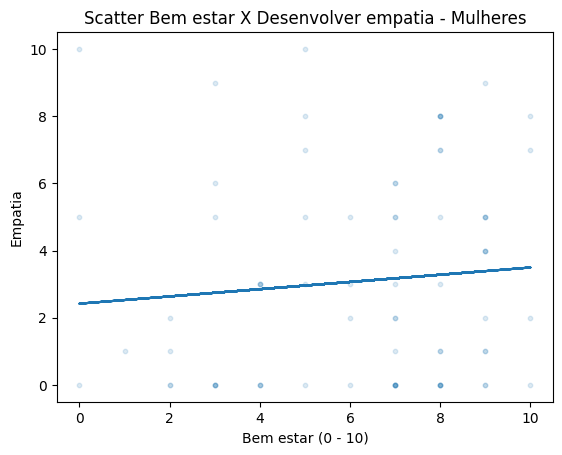

Correlação: 0.0923606382340036
R²: 0.008530487494992488


In [31]:
xData, yData = analiseMulheres1["bem-estar emocional"], analiseMulheres1["empatia-ia"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Bem estar X Desenvolver empatia - Mulheres")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Bem estar (0 - 10)")
plt.ylabel("Empatia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

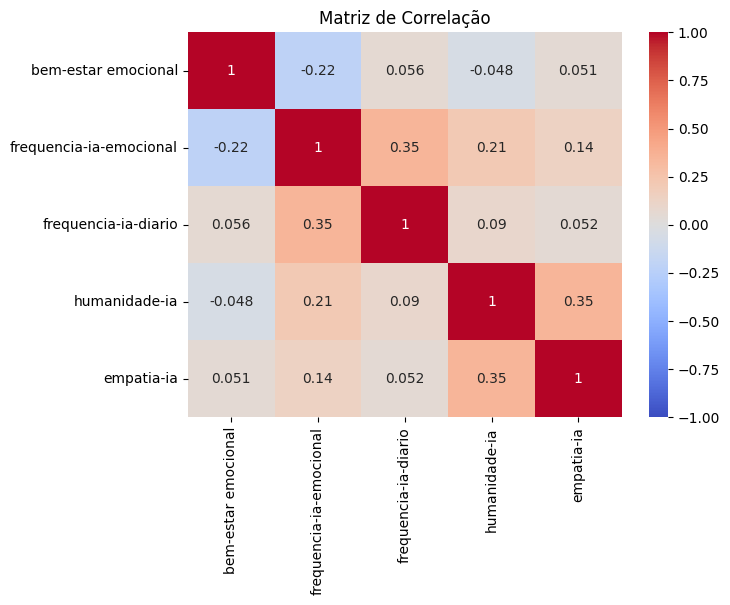

In [32]:
corr = analise1.corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação")
plt.show()

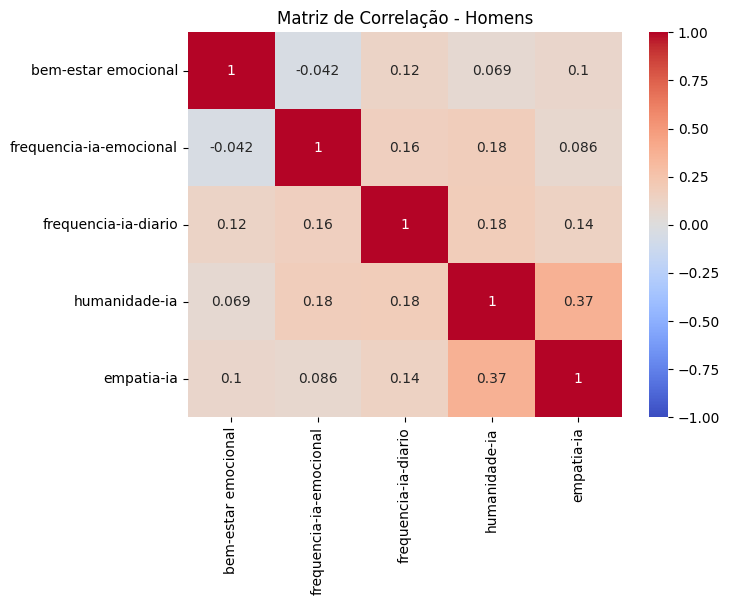

In [33]:
corr = analiseHomens1.corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação - Homens")
plt.show()

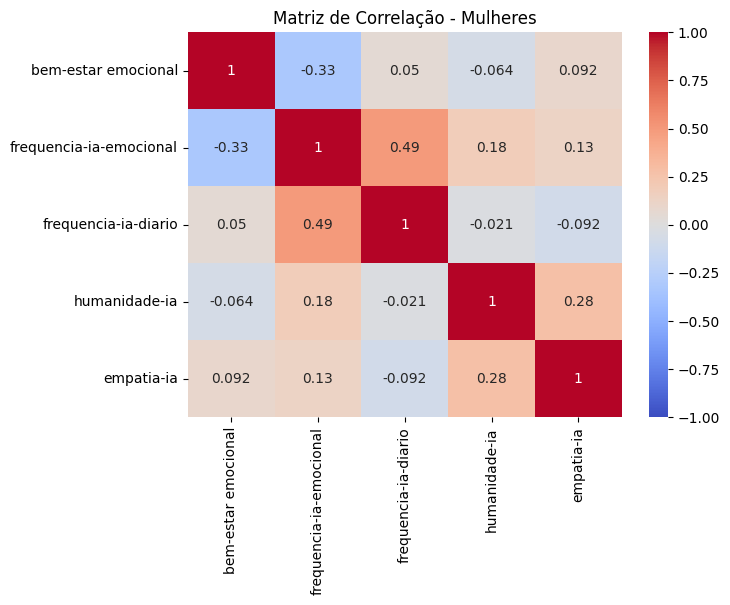

In [34]:
corr = analiseMulheres1.corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação - Mulheres")
plt.show()

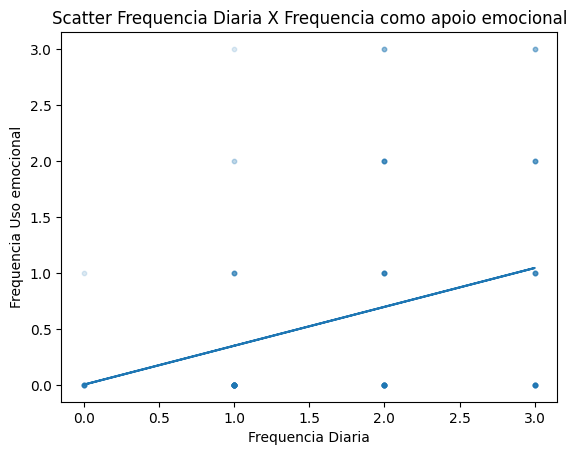

Correlação: 0.3504549745320342
R²: 0.12281868917424876


In [35]:
xData, yData = analise1["frequencia-ia-diario"], analise1["frequencia-ia-emocional"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Frequencia Diaria X Frequencia como apoio emocional")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Frequencia Diaria")
plt.ylabel("Frequencia Uso emocional")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

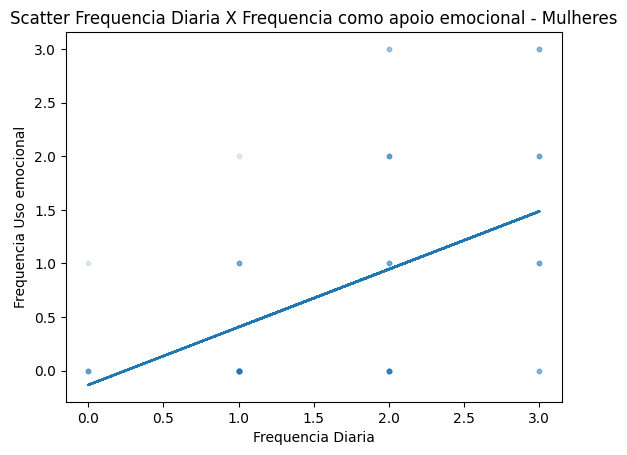

Correlação: 0.49272485806200306
R²: 0.24277778575222106


In [36]:
xData, yData = analiseMulheres1["frequencia-ia-diario"], analiseMulheres1["frequencia-ia-emocional"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Frequencia Diaria X Frequencia como apoio emocional - Mulheres")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Frequencia Diaria")
plt.ylabel("Frequencia Uso emocional")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

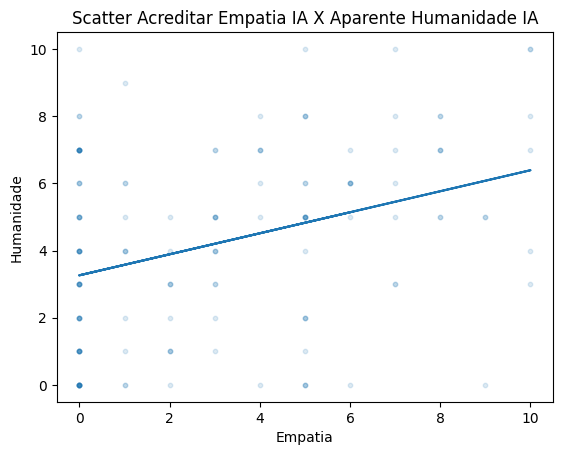

Correlação: 0.34938952542001445
R²: 0.12207304047322293


In [37]:
xData, yData = analise1["empatia-ia"], analise1["humanidade-ia"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter Acreditar Empatia IA X Aparente Humanidade IA")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Empatia")
plt.ylabel("Humanidade")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

E se dividirmos isso para homens e mulheres?

In [38]:
# Agora podemos começar a fazer uma analise
# Primeiramente, seria interresante uma contextualização
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def pizza_chart(
    labels: list[str],
    values: list[float],
    title: str = "Gráfico de Pizza",
    colors: list[str] | None = None,
    figsize: tuple = (8, 6),
    border_color: str = "white",
    border_width: float = 2.0,
    pct_distance: float = 0.75,
    legend_loc: str = "best",
    startangle: int = 90,
    explode: list[float] | None = None,
):
    """
    Cria um gráfico de pizza reutilizável.

    Parâmetros:
    -----------
    labels       : Nomes de cada fatia
    values       : Valores de cada fatia (absolutos ou percentuais)
    title        : Título do gráfico
    colors       : Lista de cores (opcional; usa paleta padrão se None)
    figsize      : Tamanho da figura (largura, altura)
    border_color : Cor da borda entre fatias
    border_width : Espessura da borda entre fatias
    pct_distance : Distância do percentual ao centro (0=centro, 1=borda)
    legend_loc   : Posição da legenda
    startangle   : Ângulo inicial da primeira fatia
    explode      : Lista de deslocamentos por fatia (ex: [0.05, 0, 0, 0])
    """
    default_colors = [
        "#1D9E75", "#7F77DD", "#D85A30",
        "#378ADD", "#BA7517", "#5DCAA5",
        "#E07B54", "#9B59B6", "#2ECC71",
    ]
    colors = colors or default_colors[: len(labels)]

    fig, ax = plt.subplots(figsize=figsize)

    wedges, texts, autotexts = ax.pie(
        values,
        labels=None,
        colors=colors,
        autopct="%1.1f%%",
        pctdistance=pct_distance,
        startangle=startangle,
        explode=explode,
        wedgeprops={
            "edgecolor": border_color,
            "linewidth": border_width,
        },
    )

    # Estiliza os percentuais dentro das fatias
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_fontweight("bold")
        autotext.set_color("white")

    # Título
    ax.set_title(title, fontsize=14, fontweight="bold", pad=16)

    # Legenda com nomes e percentuais
    total = sum(values)
    legend_labels = [
        f"{label}  ({v / total * 100:.1f}%)"
        for label, v in zip(labels, values)
    ]
    patches = [
        mpatches.Patch(color=c, label=l)
        for c, l in zip(colors, legend_labels)
    ]
    ax.legend(handles=patches, loc=legend_loc, fontsize=10, framealpha=0.8)

    plt.tight_layout()
    plt.show()

In [39]:
analise1["bem-estar emocional"].value_counts()

bem-estar emocional
7     32
8     32
9     20
6     13
3     12
4     12
5     10
0      7
10     7
2      5
1      2
Name: count, dtype: int64

In [40]:
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    texto = ''.join(
        c for c in unicodedata.normalize("NFD", texto)
        if unicodedata.category(c) != "Mn"
    )
    texto = " ".join(texto.split())
    return texto

def encontrar_coluna(colunas, trecho):
    trecho_normalizado = normalizar_texto(trecho)
    
    for coluna in colunas:
        if trecho_normalizado in normalizar_texto(coluna):
            return coluna
    
    return None

def formatar_dados(dados):
    dadosFormatados = dados.copy()

    mapa_frequencia_diario = {
        "nunca": 0,
        "as vezes": 1,
        "frequentemente": 2,
        "todos os dias": 3
    }

    mapa_frequencia_emocional = {
        "nunca": 0,
        "raramente": 1,
        "as vezes": 2,
        "frequentemente": 3
    }

    mapa_bem_estar = {
        "piora muito": 0,
        "piora": 1,
        "indiferente": 2,
        "melhora": 3,
        "melhora muito": 4
    }

    col_frequencia_diario = encontrar_coluna(
        dadosFormatados.columns,
        "Com que frequência você utiliza IA no seu dia a dia?"
    )

    col_frequencia_emocional = encontrar_coluna(
        dadosFormatados.columns,
        "Com que frequência você tem utilizado a IA para apoio emocional ou desabafo?"
    )

    col_bem_estar = encontrar_coluna(
        dadosFormatados.columns,
        "Após conversar com IA, como fica seu bem-estar?"
    )

    if col_frequencia_diario is not None:
        dadosFormatados[col_frequencia_diario] = dadosFormatados[col_frequencia_diario].apply(
            lambda x: mapa_frequencia_diario.get(normalizar_texto(x), pd.NA) if pd.notna(x) else pd.NA
        ).astype("Int64")

    if col_frequencia_emocional is not None:
        dadosFormatados[col_frequencia_emocional] = dadosFormatados[col_frequencia_emocional].apply(
            lambda x: mapa_frequencia_emocional.get(normalizar_texto(x), pd.NA) if pd.notna(x) else pd.NA
        ).astype("Int64")

    if col_bem_estar is not None:
        dadosFormatados[col_bem_estar] = dadosFormatados[col_bem_estar].apply(
            lambda x: mapa_bem_estar.get(normalizar_texto(x), pd.NA) if pd.notna(x) else pd.NA
        ).astype("Int64")

    return dadosFormatados

In [41]:
dadosFormatados = formatar_dados(dados)

In [42]:
dadosFormatados

,Carimbo de data/hora,Pontuação,Declaração de concordância com o termo dessa pesquisa,Qual é a sua faixa etária?,Qual é o seu gênero?,"Qual é seu salário mensal?\n(Salário mínimo atual: R$ 1.621,00)",Qual área você está cursando/atuando no momento?,"Em uma escala de 0 a 10, como você avalia seu bem-estar emocional atualmente?",Você faz algum acompanhamento psicólogo?(Observação: com profissional humano),"Qual(is) IA(s) você mais utiliza? Você pode marcar até três opções nessa pergunta.\nObs: Se você não utiliza, só marcar em ""Outro"" e falar que não utiliza.",...,"Em uma escala de 0 a 10, você acredita que a IA pode desenvolver empatia real?",Com que frequência você tem utilizado a IA para apoio emocional ou desabafo?,"Após conversar com IA, como fica seu bem-estar?","Em uma escala de 0 a 10, com que frequência você recorre à IA em momentos de estresse ou ansiedade?","Em uma escala de 0 a 10, o quanto você sente um nível de dependência emocional ao usar IA?",Conversar com IA já influenciou decisões importantes da sua vida?,Você sente que conversar com IA pode substituir terapia profissional?,Você se sente mais à vontade desabafando com IA do que com pessoas reais?,Você já compartilhou algo com IA que nunca contou a outra pessoa?,Se quiser compartilhar conosco (é opcional): como a IA impacta sua vida emocional?
0,23/04/2026 01:40:10,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Masculino,Não possuo renda,Engenharia da Computação,7,Não,"ChatGPT, Google Gemini, Claude",...,6,0,2,3,4,Não,"Não, de jeito nenhum.",Não,Não,nao quero
1,23/04/2026 01:44:03,NaN,Declaro que li e estou ciente das informações ...,50+ anos,Feminino,De 1 a 3 salários mínimos,Educação Física,9,Sim,ChatGPT,...,4,0,2,0,0,Não,"Não, de jeito nenhum.",Não,Não,NaN
2,23/04/2026 01:44:06,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Masculino,Não possuo renda,Ciência da Computação,3,Sim,"ChatGPT, Google Gemini, Microsoft Copilot, Claude",...,4,0,2,0,0,Sim,"Não, de jeito nenhum.",Não,Não,NaN
3,23/04/2026 06:09:25,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Masculino,Até 1 salário mínimo,Administração,3,Não,"ChatGPT, Meta AI, DeepSeek",...,0,0,2,0,0,Não sei dizer,"Não, de jeito nenhum.",Não,Sim,NaN
4,23/04/2026 07:54:04,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Feminino,Não possuo renda,Ciência da Computação,5,Não,"ChatGPT, Google Gemini, Microsoft Copilot",...,0,0,3,2,1,Não sei dizer,"Não, de jeito nenhum.",Não,Não,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,26/04/2026 15:35:11,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Feminino,Não possuo renda,Direito,7,Não,"ChatGPT, Google Gemini",...,0,1,2,0,0,Sim,"Não, de jeito nenhum.",Não,Não,NaN
148,26/04/2026 15:55:05,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Masculino,Não possuo renda,Direito,6,Sim,"ChatGPT, Google Gemini",...,5,1,3,2,0,Sim,"Não, de jeito nenhum.",Depende,Sim,NaN
149,27/04/2026 11:42:27,NaN,Declaro que li e estou ciente das informações ...,18 - 29 anos,Masculino,Não possuo renda,Ciência da Computação,8,Sim,"ChatGPT, Google Gemini, Claude",...,2,1,3,3,1,Sim,"Não, de jeito nenhum.",Não,Não,NaN
150,27/04/2026 17:33:52,NaN,Declaro que li e estou ciente das informações ...,40 - 49 anos,Masculino,De 1 a 3 salários mínimos,Ciência da Computação,7,Não,Meta AI,...,0,0,2,0,0,Não,"Não, de jeito nenhum.",Não,Não,NaN


In [43]:
dadosFormatados.columns

Index(['Carimbo de data/hora', 'Pontuação',
       'Declaração de concordância com o termo dessa pesquisa',
       'Qual é a sua faixa etária?', 'Qual é o seu gênero?',
       'Qual é seu salário mensal?\n(Salário mínimo atual: R$ 1.621,00)',
       'Qual área você está cursando/atuando no momento?',
       'Em uma escala de 0 a 10,  como você avalia seu bem-estar emocional atualmente?',
       'Você faz algum acompanhamento psicólogo?(Observação: com profissional humano)',
       'Qual(is) IA(s) você mais utiliza? Você pode marcar até três opções nessa pergunta.\nObs: Se você não utiliza, só marcar em "Outro" e falar que não utiliza.',
       'Você possui um plano pago do seu serviço de IA?',
       'Com que frequência você utiliza IA no seu dia a dia? ',
       '  Você costuma dar nome à IA que utiliza?  ',
       '  Como você se refere à IA durante conversas?  ',
       '  Em uma escala de 0 a 10, quão “humana” a IA parece para você?  ',
       'Em uma escala de 0 a 10,  você acredi

In [44]:
dadosParaAnalise = dadosFormatados[[
       'Qual é a sua faixa etária?', 
       'Qual é o seu gênero?',
       'Qual é seu salário mensal?\n(Salário mínimo atual: R$ 1.621,00)',
       'Qual área você está cursando/atuando no momento?',
       'Em uma escala de 0 a 10,  como você avalia seu bem-estar emocional atualmente?',
       'Você faz algum acompanhamento psicólogo?(Observação: com profissional humano)',
       'Qual(is) IA(s) você mais utiliza? Você pode marcar até três opções nessa pergunta.\nObs: Se você não utiliza, só marcar em "Outro" e falar que não utiliza.',
       'Você possui um plano pago do seu serviço de IA?',
       'Com que frequência você utiliza IA no seu dia a dia? ',
       '  Você costuma dar nome à IA que utiliza?  ',
       '  Como você se refere à IA durante conversas?  ',
       '  Em uma escala de 0 a 10, quão “humana” a IA parece para você?  ',
       'Em uma escala de 0 a 10,  você acredita que a IA pode desenvolver empatia real? ',
       'Com que frequência você tem utilizado a IA para apoio emocional ou desabafo?  ',
       'Após conversar com IA, como fica seu bem-estar?  ',
       'Em uma escala de 0 a 10, com que frequência você recorre à IA em momentos de estresse ou ansiedade?',
       'Em uma escala de 0 a 10, o quanto você sente um nível de dependência emocional ao usar IA? ',
       'Conversar com IA já influenciou decisões importantes da sua vida? ',
       'Você sente que conversar com IA pode substituir terapia profissional?  ',
       'Você se sente mais à vontade desabafando com IA do que com pessoas reais?  ',
       'Você já compartilhou algo com IA que nunca contou a outra pessoa?  ',
]]

In [45]:
dadosParaAnalise

,Qual é a sua faixa etária?,Qual é o seu gênero?,"Qual é seu salário mensal?\n(Salário mínimo atual: R$ 1.621,00)",Qual área você está cursando/atuando no momento?,"Em uma escala de 0 a 10, como você avalia seu bem-estar emocional atualmente?",Você faz algum acompanhamento psicólogo?(Observação: com profissional humano),"Qual(is) IA(s) você mais utiliza? Você pode marcar até três opções nessa pergunta.\nObs: Se você não utiliza, só marcar em ""Outro"" e falar que não utiliza.",Você possui um plano pago do seu serviço de IA?,Com que frequência você utiliza IA no seu dia a dia?,Você costuma dar nome à IA que utiliza?,...,"Em uma escala de 0 a 10, quão “humana” a IA parece para você?","Em uma escala de 0 a 10, você acredita que a IA pode desenvolver empatia real?",Com que frequência você tem utilizado a IA para apoio emocional ou desabafo?,"Após conversar com IA, como fica seu bem-estar?","Em uma escala de 0 a 10, com que frequência você recorre à IA em momentos de estresse ou ansiedade?","Em uma escala de 0 a 10, o quanto você sente um nível de dependência emocional ao usar IA?",Conversar com IA já influenciou decisões importantes da sua vida?,Você sente que conversar com IA pode substituir terapia profissional?,Você se sente mais à vontade desabafando com IA do que com pessoas reais?,Você já compartilhou algo com IA que nunca contou a outra pessoa?
0,18 - 29 anos,Masculino,Não possuo renda,Engenharia da Computação,7,Não,"ChatGPT, Google Gemini, Claude",Não,1,Não,...,5,6,0,2,3,4,Não,"Não, de jeito nenhum.",Não,Não
1,50+ anos,Feminino,De 1 a 3 salários mínimos,Educação Física,9,Sim,ChatGPT,Não,1,Sim,...,0,4,0,2,0,0,Não,"Não, de jeito nenhum.",Não,Não
2,18 - 29 anos,Masculino,Não possuo renda,Ciência da Computação,3,Sim,"ChatGPT, Google Gemini, Microsoft Copilot, Claude",Não,2,Não,...,7,4,0,2,0,0,Sim,"Não, de jeito nenhum.",Não,Não
3,18 - 29 anos,Masculino,Até 1 salário mínimo,Administração,3,Não,"ChatGPT, Meta AI, DeepSeek",Não,0,Não,...,0,0,0,2,0,0,Não sei dizer,"Não, de jeito nenhum.",Não,Sim
4,18 - 29 anos,Feminino,Não possuo renda,Ciência da Computação,5,Não,"ChatGPT, Google Gemini, Microsoft Copilot",Não,1,Não,...,4,0,0,3,2,1,Não sei dizer,"Não, de jeito nenhum.",Não,Não
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,18 - 29 anos,Feminino,Não possuo renda,Direito,7,Não,"ChatGPT, Google Gemini",Não,2,Não,...,7,0,1,2,0,0,Sim,"Não, de jeito nenhum.",Não,Não
148,18 - 29 anos,Masculino,Não possuo renda,Direito,6,Sim,"ChatGPT, Google Gemini",Não,2,Não,...,5,5,1,3,2,0,Sim,"Não, de jeito nenhum.",Depende,Sim
149,18 - 29 anos,Masculino,Não possuo renda,Ciência da Computação,8,Sim,"ChatGPT, Google Gemini, Claude",Estou pensando em comprar...,3,Não,...,5,2,1,3,3,1,Sim,"Não, de jeito nenhum.",Não,Não
150,40 - 49 anos,Masculino,De 1 a 3 salários mínimos,Ciência da Computação,7,Não,Meta AI,Não,1,Não,...,0,0,0,2,0,0,Não,"Não, de jeito nenhum.",Não,Não


In [46]:
dadosParaAnalise.columns

Index(['Qual é a sua faixa etária?', 'Qual é o seu gênero?',
       'Qual é seu salário mensal?\n(Salário mínimo atual: R$ 1.621,00)',
       'Qual área você está cursando/atuando no momento?',
       'Em uma escala de 0 a 10,  como você avalia seu bem-estar emocional atualmente?',
       'Você faz algum acompanhamento psicólogo?(Observação: com profissional humano)',
       'Qual(is) IA(s) você mais utiliza? Você pode marcar até três opções nessa pergunta.\nObs: Se você não utiliza, só marcar em "Outro" e falar que não utiliza.',
       'Você possui um plano pago do seu serviço de IA?',
       'Com que frequência você utiliza IA no seu dia a dia? ',
       '  Você costuma dar nome à IA que utiliza?  ',
       '  Como você se refere à IA durante conversas?  ',
       '  Em uma escala de 0 a 10, quão “humana” a IA parece para você?  ',
       'Em uma escala de 0 a 10,  você acredita que a IA pode desenvolver empatia real? ',
       'Com que frequência você tem utilizado a IA para apoio 

In [47]:
dadosParaAnalise.columns = ["faixa-etaria", "genero", "salario", "curso", "bem-estar", "acompanhamento-psi", "ias-utilizadas", "plano-ia", "frequencia-diaria", "nome-para-ia", "genero-ia", "humanidade-ia", "empatia-ia", "frequencia-ia-emocional", "bem-estar-apos-ia", "ia-quando-estresse", "dependencia-emocional-ia", "ia-influencia", "ia-sub-terapia", "tranquilo-desabafar-ia", "ia-compartilhar"]

In [48]:
dadosParaAnalise

,faixa-etaria,genero,salario,curso,bem-estar,acompanhamento-psi,ias-utilizadas,plano-ia,frequencia-diaria,nome-para-ia,...,humanidade-ia,empatia-ia,frequencia-ia-emocional,bem-estar-apos-ia,ia-quando-estresse,dependencia-emocional-ia,ia-influencia,ia-sub-terapia,tranquilo-desabafar-ia,ia-compartilhar
0,18 - 29 anos,Masculino,Não possuo renda,Engenharia da Computação,7,Não,"ChatGPT, Google Gemini, Claude",Não,1,Não,...,5,6,0,2,3,4,Não,"Não, de jeito nenhum.",Não,Não
1,50+ anos,Feminino,De 1 a 3 salários mínimos,Educação Física,9,Sim,ChatGPT,Não,1,Sim,...,0,4,0,2,0,0,Não,"Não, de jeito nenhum.",Não,Não
2,18 - 29 anos,Masculino,Não possuo renda,Ciência da Computação,3,Sim,"ChatGPT, Google Gemini, Microsoft Copilot, Claude",Não,2,Não,...,7,4,0,2,0,0,Sim,"Não, de jeito nenhum.",Não,Não
3,18 - 29 anos,Masculino,Até 1 salário mínimo,Administração,3,Não,"ChatGPT, Meta AI, DeepSeek",Não,0,Não,...,0,0,0,2,0,0,Não sei dizer,"Não, de jeito nenhum.",Não,Sim
4,18 - 29 anos,Feminino,Não possuo renda,Ciência da Computação,5,Não,"ChatGPT, Google Gemini, Microsoft Copilot",Não,1,Não,...,4,0,0,3,2,1,Não sei dizer,"Não, de jeito nenhum.",Não,Não
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,18 - 29 anos,Feminino,Não possuo renda,Direito,7,Não,"ChatGPT, Google Gemini",Não,2,Não,...,7,0,1,2,0,0,Sim,"Não, de jeito nenhum.",Não,Não
148,18 - 29 anos,Masculino,Não possuo renda,Direito,6,Sim,"ChatGPT, Google Gemini",Não,2,Não,...,5,5,1,3,2,0,Sim,"Não, de jeito nenhum.",Depende,Sim
149,18 - 29 anos,Masculino,Não possuo renda,Ciência da Computação,8,Sim,"ChatGPT, Google Gemini, Claude",Estou pensando em comprar...,3,Não,...,5,2,1,3,3,1,Sim,"Não, de jeito nenhum.",Não,Não
150,40 - 49 anos,Masculino,De 1 a 3 salários mínimos,Ciência da Computação,7,Não,Meta AI,Não,1,Não,...,0,0,0,2,0,0,Não,"Não, de jeito nenhum.",Não,Não


In [49]:
dadosParaAnalise.columns

Index(['faixa-etaria', 'genero', 'salario', 'curso', 'bem-estar',
       'acompanhamento-psi', 'ias-utilizadas', 'plano-ia', 'frequencia-diaria',
       'nome-para-ia', 'genero-ia', 'humanidade-ia', 'empatia-ia',
       'frequencia-ia-emocional', 'bem-estar-apos-ia', 'ia-quando-estresse',
       'dependencia-emocional-ia', 'ia-influencia', 'ia-sub-terapia',
       'tranquilo-desabafar-ia', 'ia-compartilhar'],
      dtype='str')

In [50]:
filtroNumerico = ["bem-estar", "frequencia-diaria", "humanidade-ia", "empatia-ia", "frequencia-ia-emocional", "bem-estar-apos-ia", "dependencia-emocional-ia"]
dadosNumericos = dadosParaAnalise[filtroNumerico]

In [51]:
dadosNumericos

,bem-estar,frequencia-diaria,humanidade-ia,empatia-ia,frequencia-ia-emocional,bem-estar-apos-ia,dependencia-emocional-ia
0,7,1,5,6,0,2,4
1,9,1,0,4,0,2,0
2,3,2,7,4,0,2,0
3,3,0,0,0,0,2,0
4,5,1,4,0,0,3,1
...,...,...,...,...,...,...,...
147,7,2,7,0,1,2,0
148,6,2,5,5,1,3,0
149,8,3,5,2,1,3,1
150,7,1,0,0,0,2,0


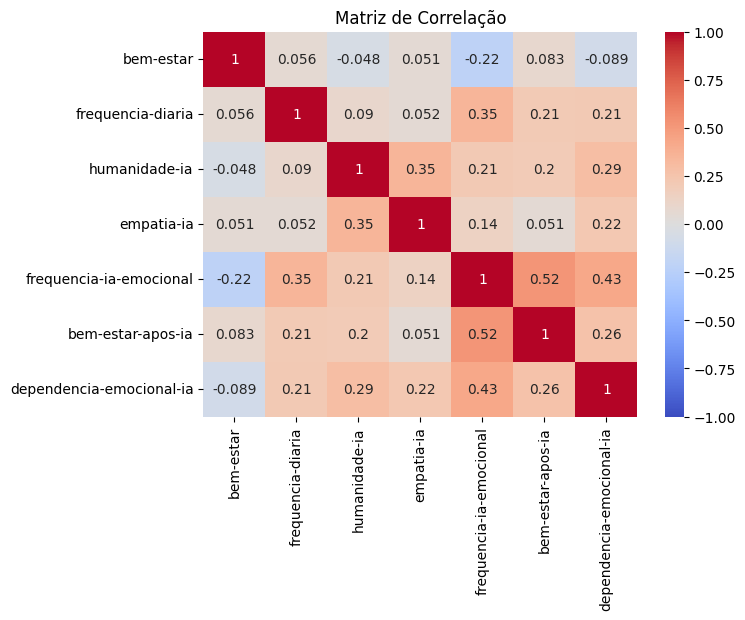

In [52]:
corr = dadosNumericos.corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação")
plt.show()

In [53]:
dadosAnaliseMasculino = dadosParaAnalise[dadosParaAnalise["genero"] == "Masculino"]
dadosAnaliseFeminino = dadosParaAnalise[dadosParaAnalise["genero"] == "Feminino"]

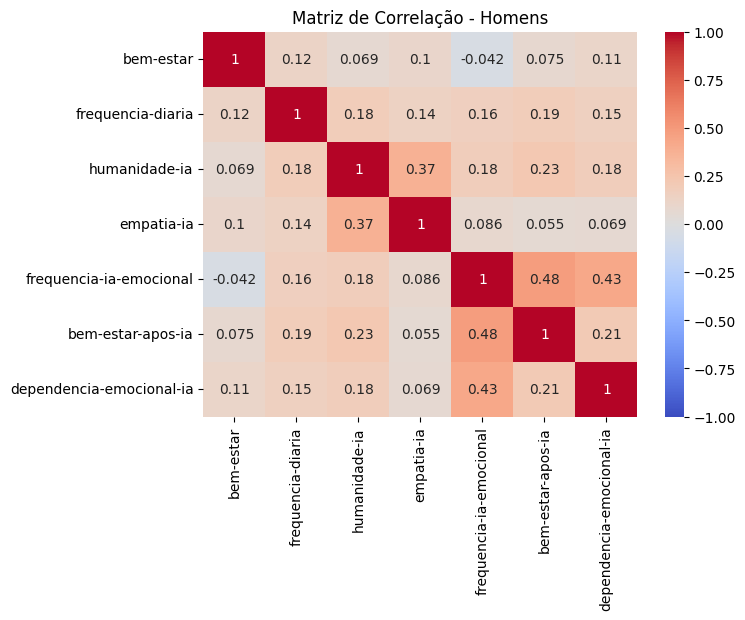

In [54]:
corr = dadosAnaliseMasculino[filtroNumerico].corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação - Homens")
plt.show()

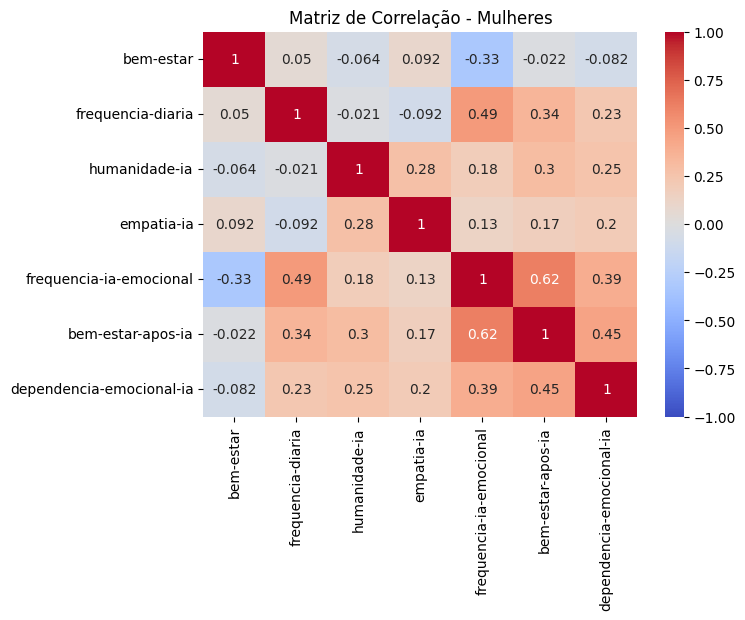

In [55]:
corr = dadosAnaliseFeminino[filtroNumerico].corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação - Mulheres")
plt.show()

In [56]:
dadosParaAnalise["salario"].value_counts()

salario
Não possuo renda                59
Até 1 salário mínimo            34
De 1 a 3 salários mínimos       28
Acima de 10 salários mínimos     9
Prefiro não informar             8
De 5 a 10 salários mínimos       7
De 3 a 5 salários mínimos        7
Name: count, dtype: int64

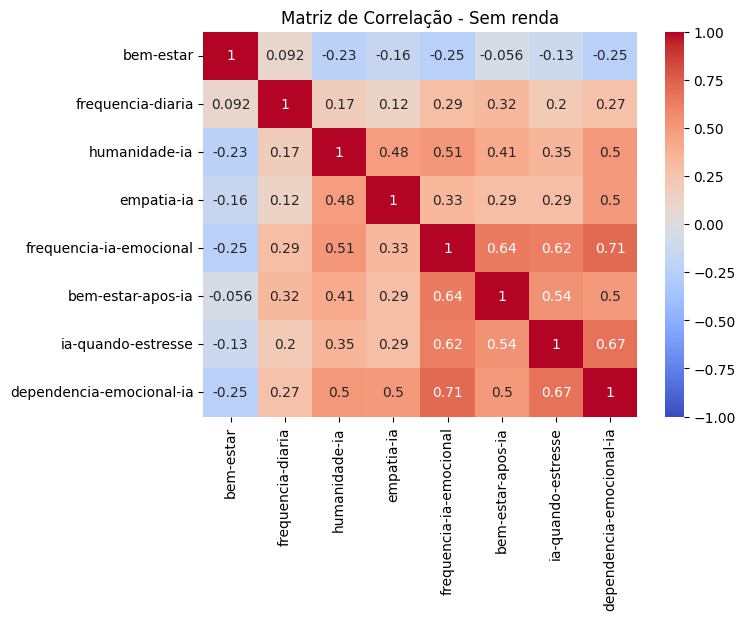

In [57]:
corr = dadosParaAnalise[dadosParaAnalise["salario"] == "Não possuo renda"].corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação - Sem renda")
plt.show()

Angular: 0.2463610586011341
Linear: 0.1832703213610584


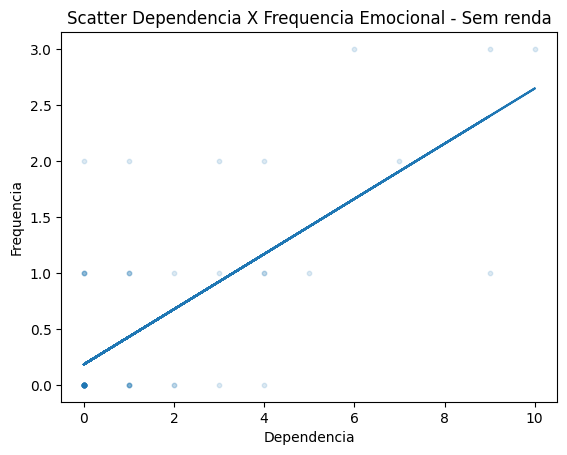

Correlação: 0.7144544981477643
R²: 0.5104452299235738


In [66]:
xData, yData = dadosParaAnalise[dadosParaAnalise["salario"] == "Não possuo renda"]["dependencia-emocional-ia"], dadosParaAnalise[dadosParaAnalise["salario"] == "Não possuo renda"]["frequencia-ia-emocional"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

print(f"Angular: {A}")
print(f"Linear: {L}")
plt.title("Scatter Dependencia X Frequencia Emocional - Sem renda")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Dependencia")
plt.ylabel("Frequencia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))


(array([ 8.,  9., 12.,  9.,  9.,  6.,  3.,  2.,  0.,  1.]),
 array([-2.51945277, -2.02406297, -1.52867316, -1.03328336, -0.53789355,
        -0.04250375,  0.45288606,  0.94827586,  1.44366567,  1.93905547,
         2.43444528]),
 <BarContainer object of 10 artists>)

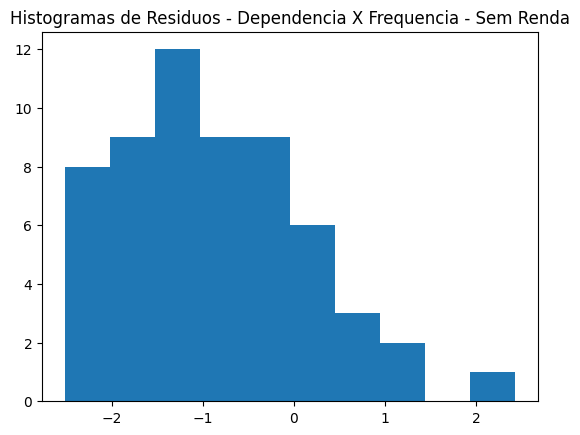

In [59]:
testX = np.linspace(0, 10, num=len(yData))
testY = A * testX + L
residuos = yData - testY
plt.title("Histogramas de Residuos - Dependencia X Frequencia - Sem Renda")
plt.hist(residuos)

In [60]:
from scipy import stats
# Teste de Shapiro-Wilk
stat, p_valor = stats.shapiro(residuos)

print(f'Estatística W: {stat:.4f}')
print(f'p-valor: {p_valor:.4f}')

Estatística W: 0.9658
p-valor: 0.0962


COMO A PORRA DO VALOR DE P FOI MAIOR QUE 0.05, REJEITAMOS A HIPOTESE NULA E TEMOS A CARALHA DA NORMALIDADE DOS RESIDUOS

In [61]:
# Coeficientes da reta
b1 = A
b0 = L

# Valores ajustados e resíduos
yHat = b0 + b1 * xData
n = len(xData)

# Somas de quadrados
SQR = np.sum((yHat - yData.mean())**2)   # Regressão
SQE = np.sum((yData - yHat)**2)          # Erro/Resíduo
SQT = SQR + SQE                      # Total

# Graus de liberdade e médias quadráticas
MQ_reg = SQR / 1
MQ_res = SQE / (n - 2)

# Estatística F
F_calc = MQ_reg / MQ_res
F_crit = stats.f.ppf(0.95, 1, n - 2)
p_valor = 1 - stats.f.cdf(F_calc, 1, n - 2)

print(f"SQR = {SQR:.4f} | SQE = {SQE:.4f} | SQT = {SQT:.4f}")
print(f"F calculado = {F_calc:.4f} | F crítico = {F_crit:.4f} | p-valor = {p_valor:.2e}")

if p_valor < 0.05:
    print("Rejeita-se H0: o modelo de regressão é estatisticamente significativo.")
else:
    print("Não se rejeita H0: o modelo não é estatisticamente significativo.")

SQR = 21.7675 | SQE = 20.8766 | SQT = 42.6441
F calculado = 59.4323 | F crítico = 4.0099 | p-valor = 2.09e-10
Rejeita-se H0: o modelo de regressão é estatisticamente significativo.


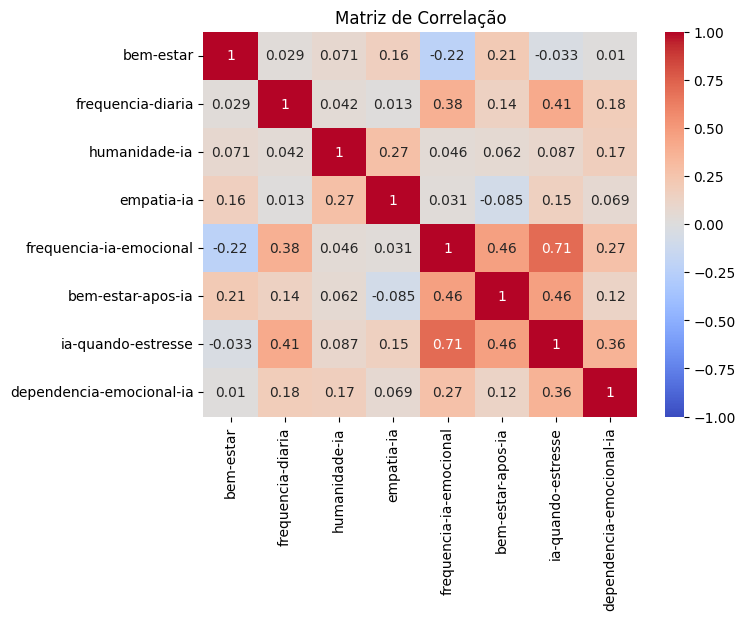

In [62]:
corr = dadosParaAnalise[dadosParaAnalise["salario"] != "Não possuo renda"].corr(numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação")
plt.show()

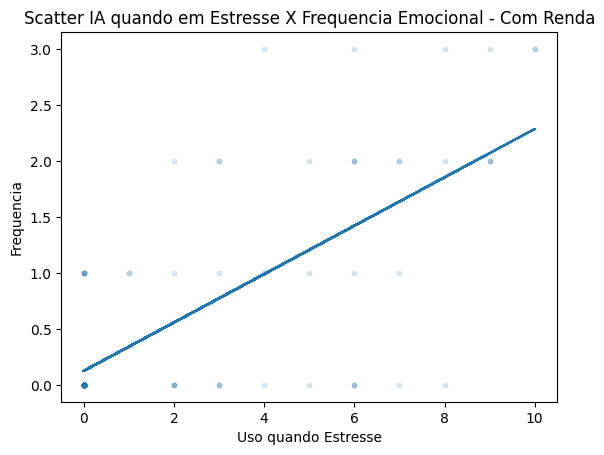

Correlação: 0.7099694711650386
R²: 0.5040566499863646


In [63]:
xData, yData = dadosParaAnalise[dadosParaAnalise["salario"] != "Não possuo renda"]["ia-quando-estresse"], dadosParaAnalise[dadosParaAnalise["salario"] != "Não possuo renda"]["frequencia-ia-emocional"]

#Reta
A, L = np.polyfit(xData, yData, deg=1)

plt.title("Scatter IA quando em Estresse X Frequencia Emocional - Com Renda")
plt.scatter(xData, yData, alpha=0.15, s=10)
plt.plot(xData, A * xData + L)
plt.xlabel("Uso quando Estresse")
plt.ylabel("Frequencia")
plt.show()
print("Correlação: " + str(np.corrcoef(xData, yData)[0, 1]))
print("R²: " + str(np.corrcoef(xData, yData)[0, 1] ** 2))

(array([15., 10., 18., 16., 11.,  6.,  4.,  6.,  4.,  3.]),
 array([-2.28537247, -1.80697994, -1.3285874 , -0.85019486, -0.37180232,
         0.10659021,  0.58498275,  1.06337529,  1.54176782,  2.02016036,
         2.4985529 ]),
 <BarContainer object of 10 artists>)

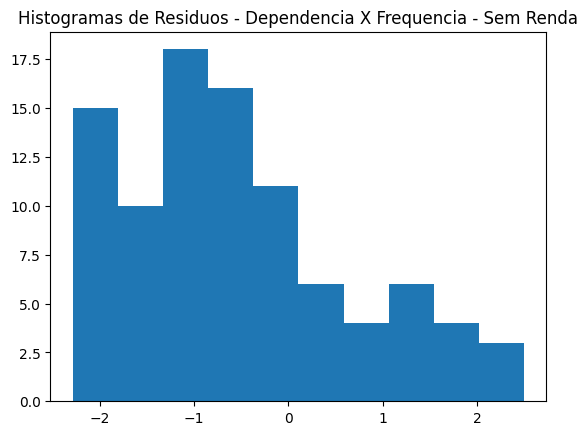

In [64]:
testX = np.linspace(0, 10, num=len(yData))
testY = A * testX + L
residuos = yData - testY
plt.title("Histogramas de Residuos - Dependencia X Frequencia - Sem Renda")
plt.hist(residuos)

In [65]:
from scipy import stats
# Teste de Shapiro-Wilk
stat, p_valor = stats.shapiro(residuos)

print(f'Estatística W: {stat:.4f}')
print(f'p-valor: {p_valor:.4f}')

Estatística W: 0.9493
p-valor: 0.0012
